# Dog Breed Classification through Transfer Learning

The models in this notebook are trained, validated and tested on a preprocessed version of the Stanford Dog dataset.
This dataset has cropped and centred all the dogs in the images to remove background noise and better highlight the relevant features. 
The efficientnet_v2 deep learning model will be used as a baseline for transfer learning. 
The simpler resnet18 base model was used previously, however, the efficient_v2 model has been deployed here for improved performance.


The Stanford Dog dataset contains:
* 120 different dog breeds
* 12000 training images (100 images per dog breed)
* 8585 testing images
  
The data is available at: <ins>https://www.kaggle.com/datasets/miljan/stanford-dogs-dataset-traintest/data</ins>

This notebook can be run on either a CPU or NVIDIA GPU using the following device agnostic code. 

The `num_classes`parameter is defined such that experiments can be trained more quickly on only a subset of the total training data. 

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, Subset, random_split
from torchvision import datasets, models
from torchvision.transforms import v2
import kagglehub
import shutil
from pathlib import Path
import random
import copy
import matplotlib.pyplot as plt
from tqdm import tqdm
from timeit import default_timer as timer

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


In [3]:
class RemapSubset(Dataset):
    """Wraps a Subset and remaps labels to contiguous [0..num_classes-1]."""
    def __init__(self, subset, selected_indices):
        self.subset = subset
        self.label_map = {old: new for new, old in enumerate(selected_indices)}

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        x, y = self.subset[idx]
        return x, self.label_map[y]

In [4]:
def load_kaggle(data_root="data/",
                dataset_name="miljan/stanford-dogs-dataset-traintest",
                num_classes=None,
                batch_size=32,
                seed=42,
                val_split=0.1):
    """
    Download, prepare and optionally subset the Stanford Dogs dataset.
    Labels are remapped to contiguous indices when subsetting.

    Args:
        data_root (str): Root folder to store data.
        dataset_name (str): Kaggle dataset identifier.
        num_classes (int): If provided, randomly subset to this many classes.
        batch_size (int): Batch size for dataloaders.
        seed (int): Random seed for reproducibility.
        val_split (float): Portion of training data to be used as a validation set.

    Returns:
        train_dataloader, val_dataloader, test_dataloader, class_names
    """

    data_path = Path(data_root)
    image_path = data_path / "dog_breeds"

    # Download if not already present
    if not image_path.is_dir():
        print(f"{image_path} directory doesn't exist ... downloading dataset")
        image_path.mkdir(parents=True, exist_ok=True)
        original_path = kagglehub.dataset_download(dataset_name)
        shutil.copytree(original_path, image_path, dirs_exist_ok=True)
    else:
        print(f"{image_path} directory exists already ... skipping download")

    train_dir = image_path / "cropped/cropped/train"
    test_dir = image_path / "cropped/cropped/test"

    # Transforms
    train_transforms = v2.Compose([
        v2.ToImage(),
        v2.RandomResizedCrop(224, scale=(0.8, 1.0)),  
        v2.RandomHorizontalFlip(p=0.5),
        v2.ColorJitter(brightness=0.2, contrast=0.2),
        v2.RandomErasing(p=0.15),
        v2.ToDtype(torch.float32, scale=True),
        v2.Normalize(mean=[0.485, 0.456, 0.406],
                     std=[0.229, 0.224, 0.225]),
    ])

    test_transforms = v2.Compose([
        v2.ToImage(),
        v2.Resize((224,224), antialias=True),
        v2.ToDtype(torch.float32, scale=True),
        v2.Normalize(mean=[0.485, 0.456, 0.406],
                     std=[0.229, 0.224, 0.225]),
    ])


    full_train_data = datasets.ImageFolder(root=train_dir, transform=train_transforms)
    test_data = datasets.ImageFolder(root=test_dir, transform=test_transforms)

    if num_classes is not None:
        random.seed(seed)
        selected_classes = random.sample(full_train_data.classes, num_classes)
        class_to_idx = full_train_data.class_to_idx
        selected_indices = [class_to_idx[c] for c in selected_classes]

        train_subset_indices = [i for i, (_, label) in enumerate(full_train_data.samples) if label in selected_indices]
        test_subset_indices = [i for i, (_, label) in enumerate(test_data.samples) if label in selected_indices]

        full_train_data = RemapSubset(Subset(full_train_data, train_subset_indices), selected_indices)
        test_data = RemapSubset(Subset(test_data, test_subset_indices), selected_indices)

        class_names = [c.split("-", 1)[1] for c in selected_classes]
        if len(class_names) <= 5:
            print(f"Selected Classes: {class_names}")
        else:
            pass
    else:
        class_names = [c.split("-", 1)[1] for c in full_train_data.classes]

    # Split train into train + validation
    val_size = int(len(full_train_data) * val_split)
    train_size = len(full_train_data) - val_size
    train_data, val_data = random_split(full_train_data, [train_size, val_size],
                                        generator=torch.Generator().manual_seed(seed))

    train_dataloader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
    val_dataloader = DataLoader(val_data, batch_size=batch_size, shuffle=False)
    test_dataloader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

    return train_dataloader, val_dataloader, test_dataloader, class_names

In [5]:
def efficientnet_model(num_classes: int, 
                       dropout_p: float=0.3, 
                       fine_tune: bool=True):
    """
    Create an EfficientNetV2-S model adapted for custom classification tasks.

    This function loads a pretrained EfficientNetV2-S backbone, freezes all layers by default,
    and replaces the classifier head with a new dropout + linear layer suitable for the given
    number of output classes. Optionally, the classifier and the last feature block can be
    unfrozen for fine-tuning.

    Parameters
    ----------
    num_classes : int
        Number of output classes for the final classification layer.
    dropout_p : float, optional (default=0.3)
        Dropout probability applied before the final linear layer.
    fine_tune : bool, optional (default=True)
        If True, unfreezes the classifier and the last feature block ("features.6")
        to allow fine-tuning. If False, all layers remain frozen.

    Returns
    -------
    torch.nn.Module
        A modified EfficientNetV2-S model ready for training or inference on the specified
        number of classes.

    Notes
    -----
    - Uses pretrained weights (`EfficientNet_V2_S_Weights.DEFAULT`) for initialization.
    - Freezing most layers helps retain pretrained feature extraction while reducing
      training time and risk of overfitting.
    - Fine-tuning the classifier and last block allows adaptation to new datasets
      while leveraging pretrained representations.
    """

    model = models.efficientnet_v2_s(weights=models.EfficientNet_V2_S_Weights.DEFAULT)

    # Freeze all layers
    for param in model.parameters():
        param.requires_grad = False

    # Optionally unfreeze classifier + last block
    if fine_tune:
        for name, param in model.named_parameters():
            if "classifier" in name or "features.6" in name:  # last block
                param.requires_grad = True

    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=dropout_p),
        nn.Linear(in_features, num_classes)
    )
    return model

In [6]:
def train_step(model: torch.nn.Module, 
               dataloader: torch.utils.data.DataLoader, 
               loss_fn: torch.nn.Module, 
               optimizer: torch.optim.Optimizer, 
               device: torch.device):
    """
    Perform one training epoch step.
    Passes batches of data through the model, computes loss, updates weights,
    and tracks average loss and accuracy across the dataloader.

    Args:
        model (torch.nn.Module): The model to train.
        dataloader (torch.utils.data.DataLoader): DataLoader providing training batches.
        loss_fn (torch.nn.Module): Loss function to optimize.
        optimizer (torch.optim.Optimizer): Optimizer used to update model parameters.
        device (torch.device): Target device for computation ("cuda" or "cpu").

    Returns:
        tuple(float, float): Average training loss and average training accuracy for the epoch.

    """
    model.to(device)
    model.train()
    train_loss, train_acc = 0, 0
    for X, y in dataloader:
        X, y = X.to(device), y.to(device)
        logits = model(X)
        loss = loss_fn(logits, y)
        train_loss += loss.item()
        preds = torch.softmax(logits, dim=1).argmax(dim=1)
        train_acc += (preds == y).sum().item() / len(y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    return train_loss / len(dataloader), train_acc / len(dataloader)

In [7]:
def eval_step(model: torch.nn.Module, 
              dataloader: torch.utils.data.DataLoader, 
              loss_fn: torch.nn.Module, 
              device: torch.device):
    """
    Evaluate the model on a given dataset.
    Runs inference without gradient updates, computes average loss and accuracy
    across the dataloader.

    Args:
        model (torch.nn.Module): The model to evaluate.
        dataloader (torch.utils.data.DataLoader): DataLoader providing validation or test batches.
        loss_fn (torch.nn.Module): Loss function to compute evaluation loss.
        device (torch.device): Target device for computation ("cuda" or "cpu").

    Returns:
        tuple(float, float): Average evaluation loss and average evaluation accuracy.
    """

    model.to(device)
    model.eval()
    total_loss, total_acc = 0, 0
    with torch.inference_mode():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            logits = model(X)
            loss = loss_fn(logits, y)
            total_loss += loss.item()
            preds = torch.softmax(logits, dim=1).argmax(dim=1)
            total_acc += (preds == y).sum().item() / len(y)
    return total_loss / len(dataloader), total_acc / len(dataloader)

In [8]:
class EarlyStopping:
    """
    Implements early stopping to halt training when validation loss stops improving.
    Tracks the best validation loss and stops training after a patience threshold
    if no improvement is observed.

    Args:
        patience (int): Number of epochs to wait after last improvement before stopping.
        min_delta (float): Minimum change in validation loss to qualify as improvement.

    Attributes:
        best_loss (float or None): Best validation loss observed so far.
        counter (int): Number of consecutive epochs without improvement.
        should_stop (bool): Flag indicating whether training should stop.
    """
    def __init__(self, patience=15, min_delta=0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = None
        self.counter = 0
        self.should_stop = False

    def step(self, val_loss):
        """
        Update early stopping state based on current validation loss.

        Args:
            val_loss (float): Current epoch's validation loss.

        Returns:
            None
        """
        if self.best_loss is None:
            self.best_loss = val_loss
            return
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True

In [9]:
def plot_results(results):
    """
    Plot training and validation loss and accuracy curves.
    Displays side-by-side plots for loss and accuracy across epochs,
    and prints final test metrics if available.

    Args:
        results (dict): Dictionary containing lists of metrics with keys
            "train_loss", "train_acc", "val_loss", "val_acc",
            optionally "test_loss" and "test_acc".

    Returns:
        None
    """
    epochs = range(1, len(results["train_loss"]) + 1)
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.plot(epochs, results["train_loss"], label="Train Loss")
    plt.plot(epochs, results["val_loss"], label="Val Loss")
    plt.legend(); plt.title("Loss")
    plt.subplot(1,2,2)
    plt.plot(epochs, results["train_acc"], label="Train Acc")
    plt.plot(epochs, results["val_acc"], label="Val Acc")
    plt.legend(); plt.title("Accuracy")
    plt.show()

In [10]:
def train(model: torch.nn.Module, 
          train_dataloader: torch.utils.data.DataLoader, 
          val_dataloader: torch.utils.data.DataLoader, 
          test_dataloader: torch.utils.data.DataLoader,
          loss_fn: torch.nn.Module, 
          optimizer: torch.nn.Module, 
          scheduler: torch.optim.lr_scheduler._LRScheduler, 
          epochs: int, 
          device: torch.device, 
          early_stopping_patience: int=15):
    """
    Train a model with early stopping and learning rate scheduling.
    Runs a training loop for a specified number of epochs, evaluates on
    validation data each epoch, applies a scheduler based on validation loss,
    and stops early if validation loss does not improve for a given patience.
    Tracks and returns training, validation, and test metrics.

    Args:
        model (torch.nn.Module): The model to train and evaluate.
        train_dataloader (torch.utils.data.DataLoader): DataLoader providing training batches.
        val_dataloader (torch.utils.data.DataLoader): DataLoader providing validation batches.
        test_dataloader (torch.utils.data.DataLoader): DataLoader providing test batches.
        loss_fn (torch.nn.Module): Loss function to optimize.
        optimizer (torch.optim.Optimizer): Optimizer used to update model parameters.
        scheduler (torch.optim.lr_scheduler._LRScheduler): Scheduler adjusting learning rate based on validation loss.
        epochs (int): Maximum number of epochs to train.
        device (torch.device or str): Target device for computation ("cuda" or "cpu").
        early_stopping_patience (int): Number of epochs to wait for validation loss improvement before stopping.

    Returns:
        tuple:
            model (torch.nn.Module): The trained model (with best weights restored if early stopping triggered).
            results (dict): Dictionary containing lists of metrics:
                {
                    "train_loss": [...],
                    "train_acc": [...],
                    "val_loss": [...],
                    "val_acc": [...],
                    "test_loss": [...],
                    "test_acc": [...]
                }
    """
    
    results = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "test_loss": [], "test_acc": []}
    early_stopping = EarlyStopping(patience=early_stopping_patience)
    best_model_wts = copy.deepcopy(model.state_dict())
    start_time = timer()

    for epoch in tqdm(range(epochs), desc="Epochs"):
        # Training
        train_loss, train_acc = train_step(model, train_dataloader, loss_fn, optimizer, device)
        # Validation
        val_loss, val_acc = eval_step(model, val_dataloader, loss_fn, device)

        # Scheduler reacts to validation loss
        scheduler.step()

        # Early stopping check
        if early_stopping.best_loss is None or val_loss < early_stopping.best_loss - early_stopping.min_delta:
            best_model_wts = copy.deepcopy(model.state_dict())
        early_stopping.step(val_loss)

        if early_stopping.should_stop:
            print(f"Early stopping triggered at epoch {epoch+1}")
            model.load_state_dict(best_model_wts)
            break

        # Progress print
        if epoch == 0 or (epoch+1) % 10 == 0:
            print(f"Epoch {epoch+1} | train_loss: {train_loss:.4f} | train_acc: {train_acc*100:.2f}% "
                  f"| val_loss: {val_loss:.4f} | val_acc: {val_acc*100:.2f}% "
                  f"| LR: {optimizer.param_groups[0]['lr']:.6f}")

        # Save results
        results["train_loss"].append(train_loss)
        results["train_acc"].append(train_acc*100)
        results["val_loss"].append(val_loss)
        results["val_acc"].append(val_acc*100)

    # Final test evaluation
    test_loss, test_acc = eval_step(model, test_dataloader, loss_fn, device)
    results["test_loss"].append(test_loss)
    results["test_acc"].append(test_acc*100)

    end_time = timer()
    print(f"Training finished in {end_time-start_time:.2f} seconds")
    print(f"Final test loss: {test_loss:.4f}, test acc: {test_acc*100:.2f}%")

    plot_results(results)
    return model, results

In [11]:
def process(device: torch.device="cuda",
            num_classes: int=5,
            batch_size: int=32,
            seed: int=42,
            dropout: float=0.5,
            learning_rate: float=5e-4,
            loss_fn: torch.nn.Module=nn.CrossEntropyLoss(label_smoothing=0.1),
            epochs: int=50,
            early_stopping_patience: int=15,
            scheduling_patience: int=3,
            weight_decay: float=1e-4,
            factor: float=0.5,
            val_split: float=0.1):
    """
    End-to-end pipeline for transfer learning with EfficientNetV2-S.
    Loads and prepares the Stanford Dogs dataset, builds an EfficientNetV2-S model
    with a custom classifier head, sets up optimizer and scheduler, and
    trains the model using the defined training loop.

    Args:
        device (str): Target device for computation ("cuda" or "cpu").
        num_classes (int): Number of output classes to subset and train on.
        batch_size (int): Batch size for dataloaders.
        seed (int): Random seed for reproducibility.
        dropout (float): Dropout probability applied before the final linear layer.
        learning_rate (float): Initial learning rate for the optimizer.
        loss_fn (torch.nn.Module): Loss function to optimize (default: CrossEntropyLoss with label smoothing).
        epochs (int): Maximum number of epochs to train.
        early_stopping_patience (int): Number of epochs to wait for validation loss improvement before stopping.
        scheduling_patience (int): Number of epochs with no improvement before scheduler reduces learning rate.
        weight_decay (float): Weight decay (L2 regularization) applied by the optimizer.
        factor (float): Factor by which the scheduler reduces learning rate.
        val_split (float): Fraction of training data reserved for validation.

    Returns:
        tuple:
            model (torch.nn.Module): The trained EfficientNetV2-S model.
            results (dict): Dictionary containing training, validation, and test metrics.
            class_names (list[str]): List of class names used in training.
    """

    # Load data
    train_dataloader, val_dataloader, test_dataloader, class_names = load_kaggle(
        num_classes=num_classes,
        batch_size=batch_size,
        seed=seed,
        val_split=val_split
    )

    # Build model
    model = efficientnet_model(num_classes=num_classes, dropout_p=dropout)

    # Optimizer: AdamW with layer-wise learning rates
    optimizer = torch.optim.AdamW([
        {"params": model.classifier.parameters(), "lr": learning_rate},   # classifier head
        {"params": model.features[-1].parameters(), "lr": learning_rate * 0.02}  # last block, smaller LR
    ], weight_decay=weight_decay)

    # Scheduler: cosine annealing for smooth LR decay
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    # Train
    model, results = train(model, train_dataloader, val_dataloader, test_dataloader,
                           loss_fn, optimizer, scheduler, epochs, device,
                           early_stopping_patience=early_stopping_patience)

    return model, results, class_names

# Experiments
Identifying how the model performs on subsets of the total trainign data.

data\dog_breeds directory exists already ... skipping download


Epochs:   1%|▋                                                                         | 1/100 [00:09<15:53,  9.63s/it]

Epoch 1 | train_loss: 2.4072 | train_acc: 53.12% | val_loss: 1.8628 | val_acc: 84.38% | LR: 0.000500


Epochs:  10%|███████▎                                                                 | 10/100 [01:49<17:58, 11.98s/it]

Epoch 10 | train_loss: 0.9187 | train_acc: 91.39% | val_loss: 0.8907 | val_acc: 91.52% | LR: 0.000488


...

Epochs:  30%|█████████████████████▉                                                   | 30/100 [05:54<14:15, 12.22s/it]

Epoch 30 | train_loss: 0.8663 | train_acc: 94.24% | val_loss: 0.8937 | val_acc: 89.29% | LR: 0.000397


Epochs:  36%|██████████████████████████▎                                              | 36/100 [07:20<13:03, 12.24s/it]

Early stopping triggered at epoch 37


Training finished in 447.70 seconds
Final test loss: 0.8035, test acc: 93.90%


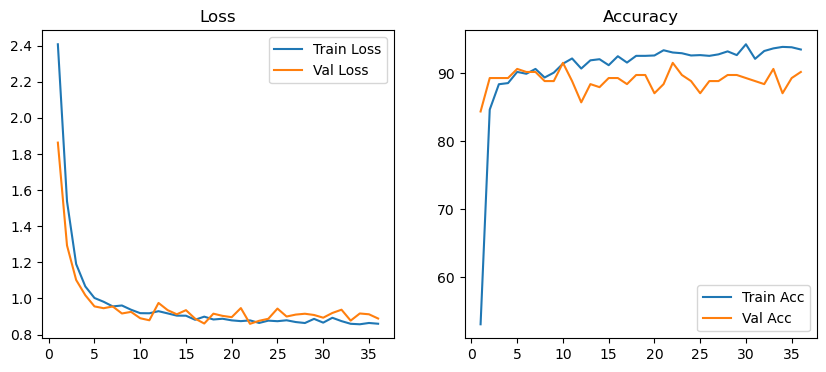

In [12]:
model_1, model_1_results, class_names = process(device=device, num_classes=20, epochs=100)

data\dog_breeds directory exists already ... skipping download


Epochs:   1%|▋                                                                         | 1/100 [00:30<51:07, 30.99s/it]

Epoch 1 | train_loss: 2.8880 | train_acc: 53.53% | val_loss: 2.0635 | val_acc: 83.91% | LR: 0.000500


Epochs:  10%|███████▎                                                                 | 10/100 [05:05<45:47, 30.53s/it]

Epoch 10 | train_loss: 1.2272 | train_acc: 85.49% | val_loss: 1.1424 | val_acc: 87.27% | LR: 0.000488


...

Epochs:  30%|█████████████████████▉                                                   | 30/100 [15:15<35:30, 30.43s/it]

Epoch 30 | train_loss: 1.1580 | train_acc: 88.32% | val_loss: 1.1351 | val_acc: 86.37% | LR: 0.000397


Epochs:  30%|█████████████████████▉                                                   | 30/100 [15:45<36:46, 31.52s/it]

Early stopping triggered at epoch 31


Training finished in 963.98 seconds
Final test loss: 1.0435, test acc: 89.81%


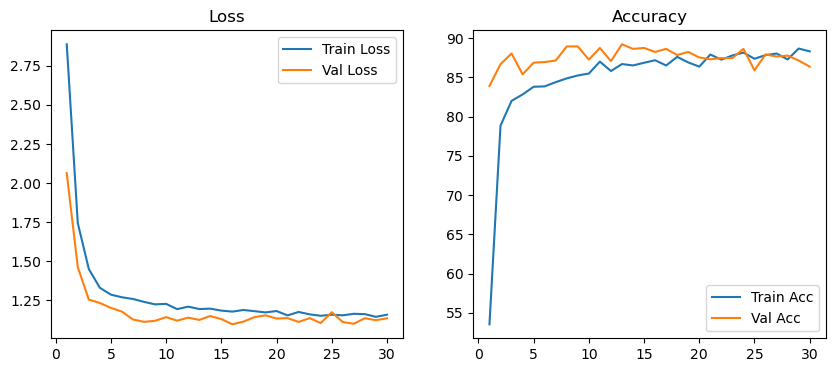

In [13]:
model_2, model_2_results, class_names = process(device=device, num_classes=50, epochs=100)

# Training the Model

Now that strong performance has been identified in the experiment cells on subsets of the data, it is time to evaluate the model when trained on the entire dataset. 

In [ ]:
model_3, model_3_results, class_names = process(device=device, num_classes=120, epochs=60)

data\dog_breeds directory exists already ... skipping download


Epochs:   2%|█▏                                                                       | 1/60 [01:16<1:15:06, 76.39s/it]

Epoch 1 | train_loss: 3.2582 | train_acc: 49.54% | val_loss: 2.2193 | val_acc: 74.01% | LR: 0.000500


Epochs:  17%|████████████                                                            | 10/60 [12:55<1:05:13, 78.28s/it]

Epoch 10 | train_loss: 1.5773 | train_acc: 77.67% | val_loss: 1.5155 | val_acc: 76.89% | LR: 0.000467


Epochs:  22%|███████████████▌                                                        | 13/60 [16:49<1:01:13, 78.15s/it]

In [ ]:
import os
import torch
import matplotlib.pyplot as plt
from torchvision.transforms import v2
from PIL import Image
import numpy as np

def pred_images(model: torch.nn.Module, 
                image_path: str, 
                class_names: list, 
                device: torch.device,
                image_extensions: list[str] = [".jpg", ".jpeg", ".png"]):
    """
    Generate predictions for a batch of images and visualize results in a grid.

    This function loads all valid image files from a given directory, applies a
    preprocessing pipeline, performs inference with a trained model, and plots
    the images alongside their predicted labels and probabilities using Matplotlib
    subplots. The breed name is displayed in bold, and the probability is shown
    in smaller text within the title.

    Parameters
    ----------
    model : torch.nn.Module
        The trained PyTorch model used for inference.
    image_path : str
        Path to the directory containing input images.
    class_names : list
        List of class names corresponding to model output indices.
    device : torch.device
        Device on which to run inference (e.g., "cpu" or "cuda").

    Returns
    -------
    predictions : list of int
        Predicted class indices for each image.
    prediction_labels : list of str
        Predicted class names for each image.
    probabilities : list of float
        Confidence scores (probabilities) for each prediction.
    images : list of PIL.Image.Image
        Original loaded images corresponding to the predictions.

    Notes
    -----
    - Only files with extensions `.jpg`, `.jpeg`, or `.png` are processed.
    - Images are resized to 224x224 and normalized to float32 before inference.
    - Results are displayed in a grid of up to 5 images per row, with unused
      subplot axes hidden.
    - Titles above each image show the predicted breed in bold and the probability
      percentage in smaller text.
    """

    transform = v2.Compose([
        v2.ToImage(),
        v2.Resize((224, 224), antialias=True),
        v2.ToDtype(torch.float32, scale=True),
    ])

    model.to(device)
    model.eval()

    predictions, prediction_labels, probabilities, images = [], [], [], []

    with torch.inference_mode():
        for img_file in os.listdir(image_path):
            # Skip non-image files or directories
            if not any(img_file.lower().endswith(ext) for ext in image_extensions):
                continue

            img_path = os.path.join(image_path, img_file)
            if not os.path.isfile(img_path):
                continue

            # Load and preprocess image
            image = Image.open(img_path).convert("RGB")
            X = transform(image).unsqueeze(0).to(device)

            # Forward pass
            logit = model(X)
            pred_probs = torch.softmax(logit, dim=1)
            prob, pred = torch.max(pred_probs, dim=1)

            # Store results
            predictions.append(pred.item())
            prediction_labels.append(class_names[pred.item()])
            probabilities.append(prob.item())
            images.append(image)

    names_spaced = [name.replace("_", " ").title() for name in prediction_labels]

    # Plot results in a grid
    n_images = len(images)
    cols = min(n_images, 5)  # up to 5 images per row
    rows = (n_images + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 5*rows), dpi=150)

    # Flatten axes for easy iteration
    if rows == 1:
        axes = axes if isinstance(axes, (list, np.ndarray)) else [axes]
    else:
        axes = axes.flatten()

    for ax, img, label, prob in zip(axes, images, names_spaced, probabilities):
        percentage = prob * 100
        ax.imshow(img)

        # Bold breed name, smaller probability in the same title
        ax.set_title(
            f"{label}\nProbability: {percentage:.2f}%",
            fontsize=10
        )
        ax.set_title(
            f"{label}\nProbability: {percentage:.2f}%",
            fontweight="bold", fontsize=12
        )

        ax.axis("off")

    # Hide unused subplots
    for ax in axes[len(images):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

    return predictions, prediction_labels, probabilities, images


In [ ]:
test_image_path = "data/dog_breeds/cropped/cropped/my_images/"
predictions, prediction_labels, probabilities, images = pred_images(model=model_3,
                                                                    image_path = test_image_path,
                                                                    class_names=class_names,
                                                                    device=device)

In [ ]:
def save_fn(model, class_names, results, filename="efficientnet_checkpoint.pth"):
    """
    Save a training checkpoint including model weights, class names, and results.

    Parameters
    ----------
    model : torch.nn.Module
        The trained model to save.
    class_names : list
        List of class names used during training.
    results : dict or any serializable object
        Training results (e.g., metrics, history).
    filename : str, optional
        Path to save the checkpoint file.
    """
    models_dir = Path("models")
    models_dir.mkdir(parents=True, exist_ok=True)

    torch.save({
        "model_state_dict": model.state_dict(),
        "class_names": class_names,
        "results": results
    }, models_dir / filename)

In [ ]:
def load_fn(num_classes, filename="efficientnet_checkpoint.pth", dropout_p=0.3, fine_tune=True):
    """
    Load a training checkpoint and reconstruct the model, class names, and results.

    Parameters
    ----------
    num_classes : int
        Number of output classes for the model architecture.
    filename : str, optional
        Path to the checkpoint file.
    dropout_p : float, optional
        Dropout probability for the classifier.
    fine_tune : bool, optional
        Whether to unfreeze classifier and last block.

    Returns
    -------
    model : torch.nn.Module
        The reconstructed model with loaded weights.
    class_names : list
        The class names from training.
    results : dict or any object
        The training results from the checkpoint.
    """
    checkpoint = torch.load(Path("models") / filename)

    model = efficientnet_model(num_classes=num_classes, dropout_p=dropout_p, fine_tune=fine_tune)
    model.load_state_dict(checkpoint["model_state_dict"])

    class_names = checkpoint["class_names"]
    results = checkpoint["results"]

    return model, class_names, results

In [ ]:
save_fn(model=model_3, class_names=class_names, results=model_3_results, filename="efficientnet_dog_breed_classifier.pth")

In [ ]:
%cd C:\Users\harri\Documents

In [ ]:
!git clone https://github.com/HarrisonOC-Creator/Projects.git
%cd Projects

In [ ]:
!git status

In [ ]:
import shutil
from pathlib import Path

# Destination inside your repo
dest = Path("deep_learning/computer_vision/classification/dog_breed_classifier")
dest.mkdir(parents=True, exist_ok=True)

# Source files
nb_src = Path(r"C:\Users\harri\Documents\coding\projects\pytorch\efficientnet.ipynb")
model_src = Path(r"C:\Users\harri\Documents\coding\projects\pytorch\models\efficientnet_dog_breed_classifier.pth")

# Copy into repo
shutil.copy(nb_src, dest / nb_src.name)
shutil.copy(model_src, dest / model_src.name)

print("Copied files to:", dest)

In [ ]:
!git add deep_learning/computer_vision/classification/dog_breed_classifier/
!git commit -m "Add efficientnet dog breed classifier notebook and model under deep_learning/computer_vision/classification"
!git push origin main